## Cell 1 — Mount Google Drive + Create Folders

In [11]:
import pandas as pd
import numpy as np
import os
import re
import nltk
import torch

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

## Cell 2 — Create folders

In [12]:
# 🔹 GLOBAL PATH (ADD THIS ONCE)

base_path = "/content/drive/MyDrive/SatyaAI"

In [13]:
# 🔹 2. Mount Drive + Load Data

from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [14]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/SatyaAI/data/raw/final.csv")

print("Initial shape:", df.shape)

Initial shape: (1311, 5)


In [15]:
# 🔹 MOUNT GOOGLE DRIVE
from google.colab import drive
import os

drive.mount('/content/drive')

# 🔹 GLOBAL PATH (ADD THIS ONCE)
base_path = "/content/drive/MyDrive/SatyaAI"

# 🔹 FUNCTION TO PRINT COMPLETE FOLDER STRUCTURE
def print_folder_structure(start_path, indent=""):
    try:
        items = sorted(os.listdir(start_path))
    except Exception as e:
        print(indent + f"[ERROR: {e}]")
        return

    for item in items:
        path = os.path.join(start_path, item)

        if os.path.isdir(path):
            print(f"{indent}📁 {item}/")
            print_folder_structure(path, indent + "    ")
        else:
            print(f"{indent}📄 {item}")

# 🔹 PRINT STRUCTURE
print(f"\n📂 Folder Structure of: {base_path}\n")
print_folder_structure(base_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📂 Folder Structure of: /content/drive/MyDrive/SatyaAI

📁 Unused folder/
    📁 All Raw Scrap Data/
        📄 altnews.csv
        📄 altnews.gsheet
        📄 boomlive_scraped.csv
        📄 boomlive_scraped.gsheet
        📄 factly_200.csv
        📄 factly_200.gsheet
        📄 indiatoday_scraped.csv
        📄 indiatoday_scraped.gsheet
        📄 vishvas_news_scraped.csv
        📄 vishvas_news_scraped.gsheet
📁 app.py/
📁 data/
    📁 processed/
        📄 dataset_cleaned.csv
        📄 dataset_cleaned.gsheet
        📄 dataset_translated.csv
        📄 test.csv
        📄 train.csv
        📄 val.csv
    📁 raw/
        📄 final.csv
        📄 final.gsheet
📁 downloaded/
📁 logs/
    📄 prediction_log.csv
📁 models/
    📄 ensemble_v2.pkl
    📄 ensemble_xlmr.pkl
    📄 logreg_v2.pkl
    📄 rf_model.pkl
    📄 rf_v2.pkl
    📄 svm_v2.pkl
    📄 tfidf_v2.pkl
    📄 xlmr_classifier.pkl
   

In [16]:
# 🔹 Create folders (MERGED CELL)

# import os

# os.makedirs(f"{base_path}/data/processed", exist_ok=True)
# os.makedirs(f"{base_path}/models", exist_ok=True)
# os.makedirs(f"{base_path}/results", exist_ok=True)
# os.makedirs(f"{base_path}/logs", exist_ok=True)

In [17]:
# 🔹 Data Balance Check (NEW)

print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

label
MISLEADING    569
FALSE         426
TRUE          316
Name: count, dtype: int64
label
MISLEADING    0.434020
FALSE         0.324943
TRUE          0.241037
Name: proportion, dtype: float64


## 4. DATA VALIDATION (IMPORTANT)

In [18]:
print("\nMissing values:\n", df.isnull().sum())

df = df.dropna(subset=['claim', 'label'])

print("\nLabel distribution:\n", df['label'].value_counts())


Missing values:
 claim       0
label       0
language    0
source      0
url         0
dtype: int64

Label distribution:
 label
MISLEADING    569
FALSE         426
TRUE          316
Name: count, dtype: int64


## 5. NLP PREPROCESSING

In [19]:
# # ─── IMPROVED PREPROCESSING (replace Cell 5 function) ─────

# import nltk
# from nltk.stem import WordNetLemmatizer
# nltk.download('wordnet')
# nltk.download('stopwords')

# lemmatizer = WordNetLemmatizer()
# stop_words = set(stopwords.words('english'))

# def preprocess_text(text):
#     text = str(text).lower()
#     text = re.sub(r'http\S+', '', text)              # remove URLs
#     text = re.sub(r'[^a-zA-Z0-9\s]', '', text)       # remove special chars
#     tokens = text.split()
#     tokens = [w for w in tokens if w not in stop_words]  # stopword removal
#     tokens = [lemmatizer.lemmatize(w) for w in tokens]   # ← LEMMATIZATION (new)
#     return " ".join(tokens)


In [20]:
# ─── IMPROVED PREPROCESSING ───────────────────────────────
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)                    # remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)            # remove special chars
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]   # remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]    # ← lemmatization (NEW)
    tokens = [w for w in tokens if len(w) > 2]            # remove very short words
    return " ".join(tokens)

print("✅ Improved preprocess_text defined with lemmatization")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Improved preprocess_text defined with lemmatization


## lemmatization

In [21]:
!pip install nltk

## 6. LOAD NLLB

In [22]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name)
nllb_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
nllb_model = nllb_model.to(device)

print("NLLB model loaded ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

NLLB model loaded ✅


## 7. TRANSLATION FUNCTION

In [23]:
def translate_nllb(text, source_lang="hin_Deva", target_lang="eng_Latn"):

    tokenizer.src_lang = source_lang

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    forced_bos_token_id = tokenizer.convert_tokens_to_ids(target_lang)

    outputs = nllb_model.generate(
        **inputs,
        forced_bos_token_id=forced_bos_token_id,
        max_length=512
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [24]:
#(translate function)
def detect_and_translate(row):
    try:
        lang = row['language']
        if lang == 'hi':                          # Pure Hindi (Devanagari)
            return translate_nllb(row['claim'], source_lang='hin_Deva')
        elif lang == 'hinglish':                  # Hinglish (Roman script)
            return translate_nllb(row['claim'], source_lang='eng_Latn')
                                                  # NLLB treats as English → still works partially
        else:
            return row['claim']                   # English — no translation needed
    except:
        return row['claim']


## 8. APPLY TRANSLATION

In [25]:
import os

translated_path = f"{base_path}/data/processed/dataset_translated.csv"

if os.path.exists(translated_path):
    print("Loading translated dataset from Drive...")
    df = pd.read_csv(translated_path)

else:
    print("Translating dataset... (runs only once)")

    def translate_row(row):
        try:
            if row['language'] in ['hi', 'hinglish']:
                return translate_nllb(row['claim'])
            return row['claim']
        except:
            return row['claim']

    df['translated'] = df.apply(translate_row, axis=1)

    df.to_csv(translated_path, index=False)

    print("Translation saved ✅")

Loading translated dataset from Drive...


## Example

In [26]:
print("🔍 Testing Translation...\n")

# Make sure tokenizer + nllb_model already loaded in previous cell

def safe_translate(text, src, tgt):
    try:
        tokenizer.src_lang = src
        inputs = tokenizer(text, return_tensors="pt", truncation=True)

        forced_bos_token_id = tokenizer.convert_tokens_to_ids(tgt)

        outputs = nllb_model.generate(
            **inputs,
            forced_bos_token_id=forced_bos_token_id,
            max_length=200
        )

        return tokenizer.decode(outputs[0], skip_special_tokens=True)

    except Exception as e:
        return f"❌ Error: {e}"


# -----------------------
# Example Inputs
# -----------------------

examples = [
    ("English", "The government announced a new policy today.", "eng_Latn"),
    ("Hindi", "सरकार ने आज एक नई नीति की घोषणा की।", "hin_Deva"),
    ("Hinglish", "yeh news bilkul fake hai aur logon ko gumrah kar rahi hai", "eng_Latn")
]

# -----------------------
# Run Translation
# -----------------------

for lang, text, src_code in examples:

    print(f"🟡 Original ({lang}): {text}")

    translated = safe_translate(text, src_code, "eng_Latn")

    print(f"🟢 Translated (English): {translated}")
    print("-" * 60)

🔍 Testing Translation...

🟡 Original (English): The government announced a new policy today.
🟢 Translated (English): The government announced a new policy today.
------------------------------------------------------------
🟡 Original (Hindi): सरकार ने आज एक नई नीति की घोषणा की।


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Server error '500 Internal Server Error' for url 'https://huggingface.co/api/models/facebook/nllb-200-distilled-600M/commits/main'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/500

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safet

🟢 Translated (English): The government today announced a new policy.
------------------------------------------------------------
🟡 Original (Hinglish): yeh news bilkul fake hai aur logon ko gumrah kar rahi hai
🟢 Translated (English): Yea news bilkul fake hai aur logon ko gumrah kar rahi hai is the first time that I have seen this.
------------------------------------------------------------


## 9. PREPROCESS TEXT

In [27]:
import os

cleaned_path = f"{base_path}/data/processed/dataset_cleaned.csv"

if os.path.exists(cleaned_path):
    print("Loading cleaned dataset from Drive...")
    df = pd.read_csv(cleaned_path)
else:
    print("Cleaning text...")
    df['clean_text'] = df['translated'].apply(preprocess_text)
    df.to_csv(cleaned_path, index=False)
    print("Saved cleaned dataset to Drive ✅")


Loading cleaned dataset from Drive...


In [28]:
# ─── TOKENIZATION STATS + SAVE TO DRIVE ───────────────────
import os

token_stats_path = f"{base_path}/results/tokenization_stats.csv"

if os.path.exists(token_stats_path):
    print("Loading tokenization stats from Drive...")
    token_stats_df = pd.read_csv(token_stats_path)
    print(token_stats_df)
else:
    print("Computing tokenization stats...")

    # Per-row token count
    df['token_count'] = df['clean_text'].apply(lambda x: len(str(x).split()))

    # Show samples
    print("=== Sample Tokenization ===\n")
    for i in range(3):
        print(f"Row {i+1}:")
        print(f"  Original : {df['claim'].iloc[i]}")
        print(f"  Tokens   : {df['clean_text'].iloc[i].split()[:10]}...")
        print()

    # Stats
    token_stats_df = pd.DataFrame({
        "Metric"  : ["Total Documents", "Avg Tokens/Doc", "Max Tokens", "Min Tokens", "Total Tokens"],
        "Value"   : [
            len(df),
            round(df['token_count'].mean(), 1),
            df['token_count'].max(),
            df['token_count'].min(),
            df['token_count'].sum()
        ]
    })

    token_stats_df.to_csv(token_stats_path, index=False)
    print(token_stats_df.to_string(index=False))
    print("\n✅ Tokenization stats saved to Drive")

Loading tokenization stats from Drive...
            Metric    Value
0  Total Documents   1311.0
1   Avg Tokens/Doc     17.9
2       Max Tokens    509.0
3       Min Tokens      1.0
4     Total Tokens  23515.0


## 10. TRAIN-TEST-VALIDATION SPLIT

In [29]:
#  10. Train–Validation–Test Split (FIXED + CONSISTENT)

from sklearn.model_selection import train_test_split
import os

# Save path
train_path = f"{base_path}/data/processed/train.csv"
val_path = f"{base_path}/data/processed/val.csv"
test_path = f"{base_path}/data/processed/test.csv"

# ✅ If already exists → load instead of splitting again
if os.path.exists(train_path) and os.path.exists(val_path) and os.path.exists(test_path):
    print("Loading existing split from Drive...")

    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

else:
    print("Creating new split...")

    train_df, temp_df = train_test_split(
        df,
        test_size=0.3,
        stratify=df['label'],
        random_state=42
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df['label'],
        random_state=42
    )

    train_df.to_csv(train_path, index=False)
    val_df.to_csv(val_path, index=False)
    test_df.to_csv(test_path, index=False)

    print("Split saved to Drive ✅")

# Debug check
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Loading existing split from Drive...
Train: (917, 7)
Val: (197, 7)
Test: (197, 7)


## 11. TF-IDF FEATURE **ENGINEERING**

In [30]:
# ─── IMPROVED TF-IDF ──────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

# Word-level TF-IDF
word_tfidf = TfidfVectorizer(
    max_features=10000,       # was 5000 → bigger vocabulary
    ngram_range=(1, 3),       # was (1,2) → add trigrams
    sublinear_tf=True,        # ← dampens high-frequency words
    min_df=2,                 # ignore words in only 1 doc
    analyzer='word'
)

# Character-level TF-IDF (catches morphological patterns)
char_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(3, 5),
    sublinear_tf=True,
    analyzer='char_wb'        # ← character n-grams (NEW)
)

# Combine both
from sklearn.pipeline import FeatureUnion
combined_tfidf = FeatureUnion([
    ('word', word_tfidf),
    ('char', char_tfidf)
])

X_train = combined_tfidf.fit_transform(train_df['clean_text'])
X_val   = combined_tfidf.transform(val_df['clean_text'])
X_test  = combined_tfidf.transform(test_df['clean_text'])

y_train = train_df['label']
y_val   = val_df['label']
y_test  = test_df['label']

print(f"✅ Combined TF-IDF shape: {X_train.shape}")


✅ Combined TF-IDF shape: (917, 7989)


/tmp/ipykernel_6622/3441741285.py:63: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6622/3441741285.py:63: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6622/3441741285.py:64: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_6622/3441741285.py:64: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


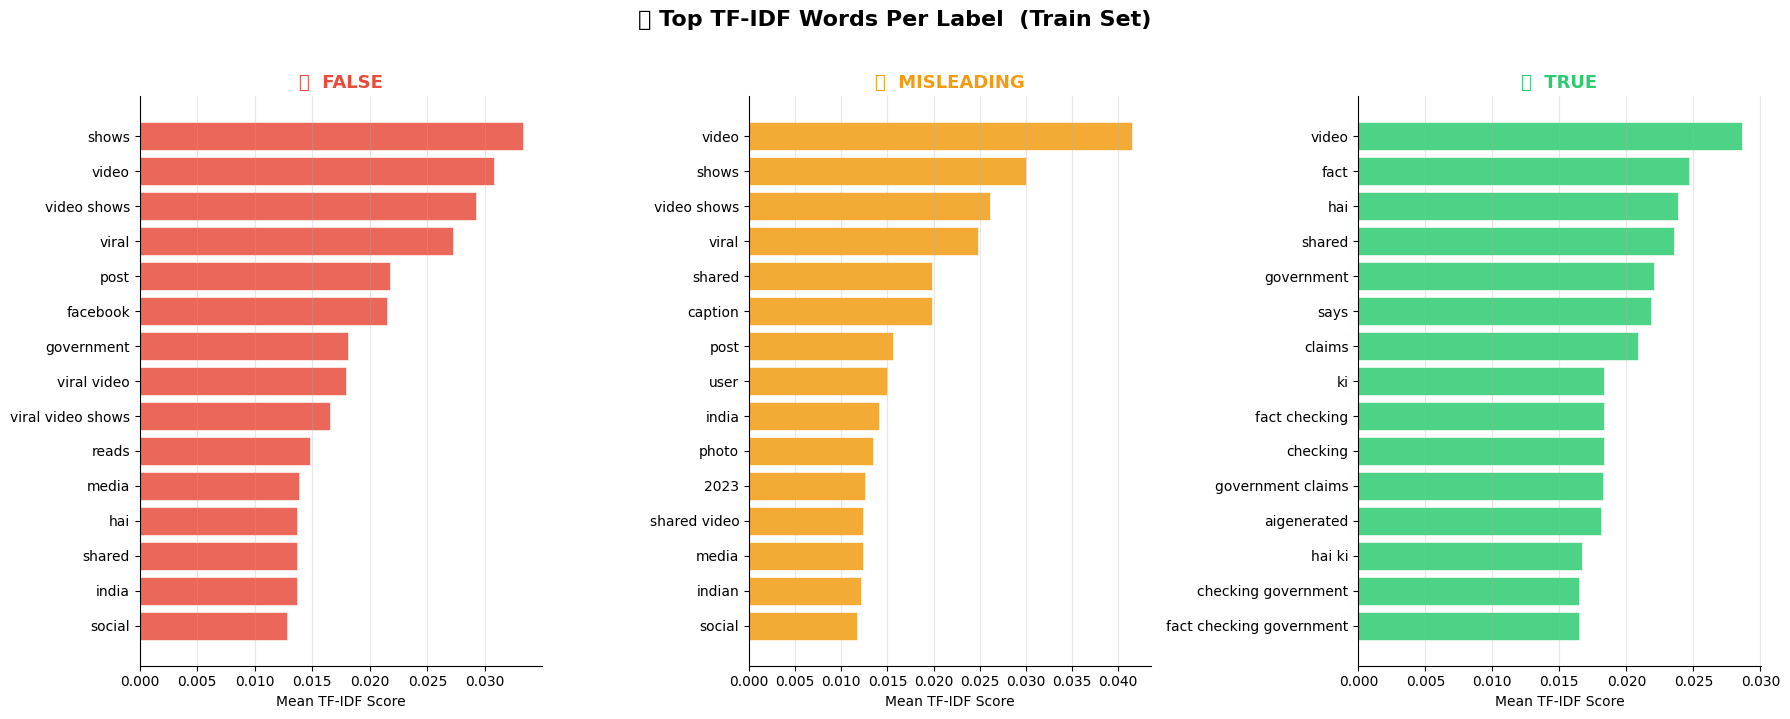

✅ Top TF-IDF words per label saved to Drive


In [31]:
# ══════════════════════════════════════════════════════════════
# 11A. TOP TF-IDF WORDS PER LABEL (Bar Chart)
# ══════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt

# Get word-level feature names from the word_tfidf part only
word_feature_names = np.array(word_tfidf.get_feature_names_out())

TOP_N  = 15
labels = sorted(train_df['label'].unique())   # FALSE, MISLEADING, TRUE
colors = {
    'FALSE'      : '#e74c3c',
    'MISLEADING' : '#f39c12',
    'TRUE'       : '#2ecc71'
}

fig, axes = plt.subplots(1, len(labels), figsize=(18, 7))
fig.suptitle(
    "📊 Top TF-IDF Words Per Label  (Train Set)",
    fontsize=16, fontweight='bold', y=1.02
)

for ax, label in zip(axes, labels):

    # Filter rows for this label
    label_mask   = (train_df['label'].values == label)
    label_matrix = X_train[label_mask, :]

    # Use only word-level columns (first len(word_feature_names) columns)
    word_cols   = label_matrix[:, :len(word_feature_names)]

    # Mean TF-IDF score per word across all docs in this label
    mean_scores = np.asarray(word_cols.mean(axis=0)).flatten()

    # Top N words
    top_indices = mean_scores.argsort()[::-1][:TOP_N]
    top_words   = word_feature_names[top_indices]
    top_scores  = mean_scores[top_indices]

    # Plot horizontal bars (reversed so highest is on top)
    ax.barh(
        range(TOP_N),
        top_scores[::-1],
        color=colors.get(label, '#3498db'),
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5
    )
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_words[::-1], fontsize=10)
    ax.set_title(
        f"🏷️  {label}",
        fontsize=13, fontweight='bold',
        color=colors.get(label, '#3498db')
    )
    ax.set_xlabel("Mean TF-IDF Score", fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    f"{base_path}/results/top_tfidf_words_per_label.png",
    bbox_inches='tight', dpi=150
)
plt.show()
print("✅ Top TF-IDF words per label saved to Drive")


/tmp/ipykernel_6622/357559760.py:48: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6622/357559760.py:49: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


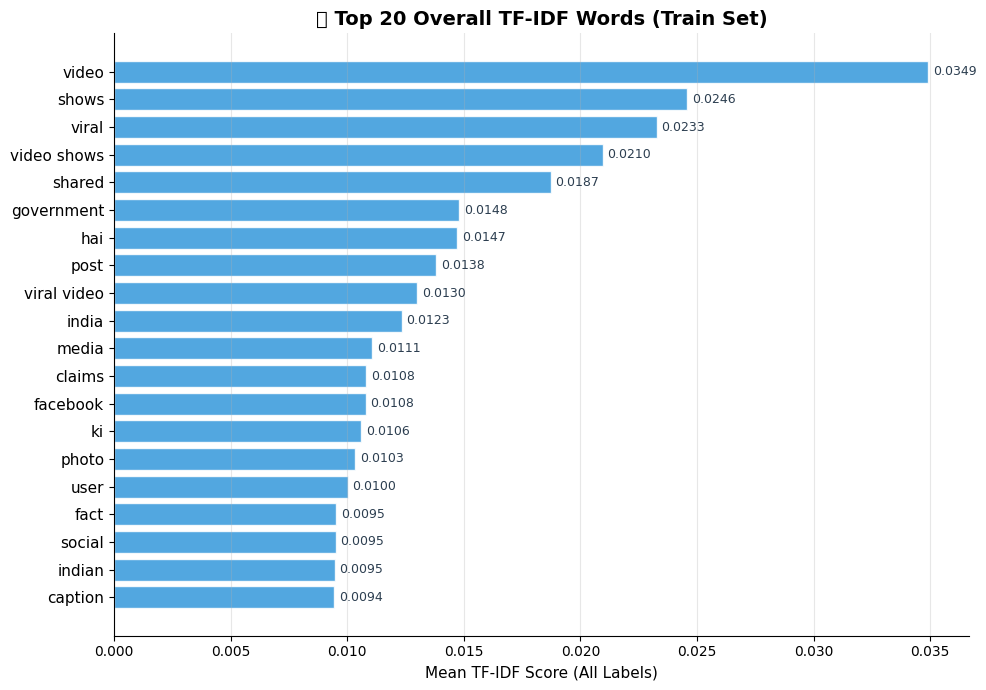


📋 TF-IDF Vocabulary Summary:
Metric                                   Value
───────────────────────────────────────────────
Total word features                      2,989
Total char features                      5,000
Total combined features                  7,989
Train samples                              917
Val samples                                197
Test samples                               197

🔝 Top 20 Most Informative Words:
 Rank Word/Phrase  Mean TF-IDF
    1       video      0.03492
    2       shows      0.02459
    3       viral      0.02327
    4 video shows      0.02097
    5      shared      0.01874
    6  government      0.01480
    7         hai      0.01472
    8        post      0.01383
    9 viral video      0.01300
   10       india      0.01233
   11       media      0.01107
   12      claims      0.01082
   13    facebook      0.01079
   14          ki      0.01059
   15       photo      0.01034
   16        user      0.01003
   17        fact      0.00953
 

In [32]:
# ══════════════════════════════════════════════════════════════
# 11B. TOP 20 OVERALL TF-IDF WORDS + WORD STATS TABLE
# ══════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

word_feature_names = np.array(word_tfidf.get_feature_names_out())

# Mean TF-IDF across ALL training samples (word columns only)
word_cols   = X_train[:, :len(word_feature_names)]
mean_scores = np.asarray(word_cols.mean(axis=0)).flatten()

TOP_N       = 20
top_indices = mean_scores.argsort()[::-1][:TOP_N]
top_words   = word_feature_names[top_indices]
top_scores  = mean_scores[top_indices]

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    range(TOP_N),
    top_scores[::-1],
    color='#3498db',
    alpha=0.85,
    edgecolor='white'
)

ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_words[::-1], fontsize=11)
ax.set_xlabel("Mean TF-IDF Score (All Labels)", fontsize=11)
ax.set_title("🔝 Top 20 Overall TF-IDF Words (Train Set)", fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add score labels on bars
for i, (bar, score) in enumerate(zip(bars, top_scores[::-1])):
    ax.text(
        bar.get_width() + 0.0002,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.4f}',
        va='center', fontsize=9, color='#2c3e50'
    )

plt.tight_layout()
plt.savefig(
    f"{base_path}/results/top_tfidf_words_overall.png",
    bbox_inches='tight', dpi=150
)
plt.show()

# ── Summary Stats Table ────────────────────────────────────────
print("\n📋 TF-IDF Vocabulary Summary:")
print(f"{'Metric':<35} {'Value':>10}")
print("─" * 47)
print(f"{'Total word features':<35} {len(word_feature_names):>10,}")
print(f"{'Total char features':<35} {5000:>10,}")
print(f"{'Total combined features':<35} {X_train.shape[1]:>10,}")
print(f"{'Train samples':<35} {X_train.shape[0]:>10,}")
print(f"{'Val samples':<35} {X_val.shape[0]:>10,}")
print(f"{'Test samples':<35} {X_test.shape[0]:>10,}")
print()

# ── Top Words Table ────────────────────────────────────────────
top_words_df = pd.DataFrame({
    'Rank'        : range(1, TOP_N + 1),
    'Word/Phrase' : top_words,
    'Mean TF-IDF' : [round(s, 5) for s in top_scores]
})
print("🔝 Top 20 Most Informative Words:")
print(top_words_df.to_string(index=False))
print("\n✅ Overall TF-IDF chart saved to Drive")


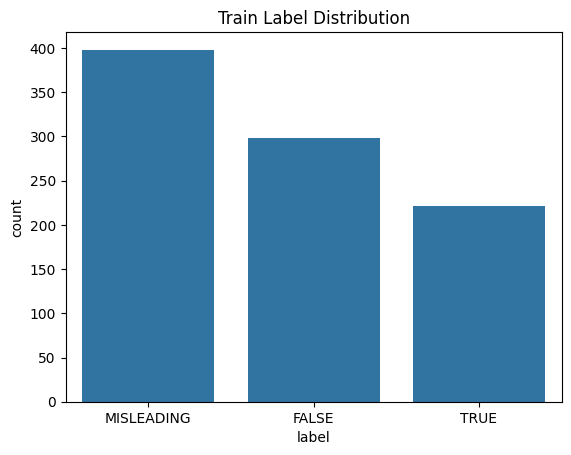

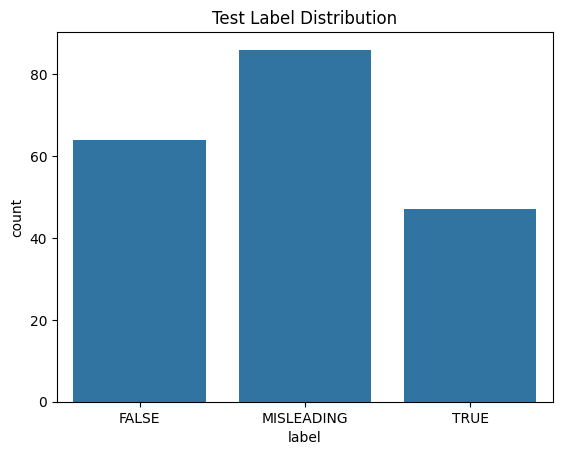

In [33]:
# 🔹 11A. Class Distribution Check

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=train_df['label'])
plt.title("Train Label Distribution")
plt.show()

sns.countplot(x=test_df['label'])
plt.title("Test Label Distribution")
plt.show()

## 12. MODEL TRAINING

## LogisticRegression

In [34]:
# ─── 12. TUNED LOGISTIC REGRESSION ────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pickle, os

lr_path  = f"{base_path}/models/logreg_v2.pkl"

if os.path.exists(lr_path):
    print("Loading tuned LR from Drive...")
    with open(lr_path, "rb") as f:
        model_lr = pickle.load(f)
    lr_preds = model_lr.predict(X_test)
else:
    print("Tuning Logistic Regression with GridSearch...")

    param_grid = {
        'C':        [0.1, 1, 5, 10, 50],
        'solver':   ['lbfgs', 'saga'],
        'max_iter': [500, 1000]
    }

    grid_lr  = GridSearchCV(
        LogisticRegression(class_weight='balanced'),
        param_grid, cv=5,
        scoring='f1_weighted',
        n_jobs=-1, verbose=1
    )
    grid_lr.fit(X_train, y_train)
    model_lr = grid_lr.best_estimator_

    print(f"Best params : {grid_lr.best_params_}")
    print(f"Best CV F1  : {round(grid_lr.best_score_*100, 2)}%")

    with open(lr_path, "wb") as f:
        pickle.dump(model_lr, f)
    print("✅ Tuned LR saved to Drive")

lr_preds = model_lr.predict(X_test)
print(f"\nLR Test Accuracy : {round(accuracy_score(y_test, lr_preds)*100, 2)}%")
print(classification_report(y_test, lr_preds))


Loading tuned LR from Drive...

LR Test Accuracy : 67.51%
              precision    recall  f1-score   support

       FALSE       0.57      0.59      0.58        64
  MISLEADING       0.71      0.62      0.66        86
        TRUE       0.76      0.89      0.82        47

    accuracy                           0.68       197
   macro avg       0.68      0.70      0.69       197
weighted avg       0.67      0.68      0.67       197



## XLM-RoBERTa

In [35]:
!pip install -q transformers torch
print("✅ Transformers ready")

✅ Transformers ready


In [36]:
# ══════════════════════════════════════════════════════════════
# 12B. XLM-RoBERTa — Cross-Lingual Transformer Classifier
# ══════════════════════════════════════════════════════════════

import os
import pickle
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ── Paths ──────────────────────────────────────────────────────
xlmr_clf_path       = f"{base_path}/models/xlmr_classifier.pkl"
xlmr_emb_train_path = f"{base_path}/models/xlmr_emb_train.npy"
xlmr_emb_test_path  = f"{base_path}/models/xlmr_emb_test.npy"

# ── Load XLM-RoBERTa Model ─────────────────────────────────────
XLMR_MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base"

print(f"🔄 Loading XLM-RoBERTa: {XLMR_MODEL_NAME}")
xlmr_tokenizer = AutoTokenizer.from_pretrained(XLMR_MODEL_NAME)
xlmr_base      = AutoModel.from_pretrained(XLMR_MODEL_NAME)

xlmr_device = "cuda" if torch.cuda.is_available() else "cpu"
xlmr_base   = xlmr_base.to(xlmr_device)
xlmr_base.eval()
print(f"✅ XLM-RoBERTa loaded on: {xlmr_device}")


# ── Embedding Extraction Function ──────────────────────────────
def get_xlmr_embeddings(texts, batch_size=16, max_length=128):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch   = texts[i : i + batch_size]
        encoded = xlmr_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        encoded = {k: v.to(xlmr_device) for k, v in encoded.items()}

        with torch.no_grad():
            output = xlmr_base(**encoded)

        cls_emb = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)

        if (i // batch_size) % 5 == 0:
            print(f"  Processed {min(i+batch_size, len(texts))}/{len(texts)} texts...")

    return np.vstack(all_embeddings)


# ── Extract or Load Embeddings ──────────────────────────────────
if os.path.exists(xlmr_emb_train_path) and os.path.exists(xlmr_emb_test_path):
    print("\n📂 Loading cached XLM-RoBERTa embeddings from Drive...")
    X_train_xlmr = np.load(xlmr_emb_train_path)
    X_test_xlmr  = np.load(xlmr_emb_test_path)
    print(f"✅ Train embeddings shape: {X_train_xlmr.shape}")
    print(f"✅ Test  embeddings shape: {X_test_xlmr.shape}")

else:
    print("\n🔄 Extracting XLM-RoBERTa embeddings (5-10 min first time)...")

    train_texts = train_df['translated'].fillna("").tolist()
    test_texts  = test_df['translated'].fillna("").tolist()

    print("  → Encoding TRAIN set...")
    X_train_xlmr = get_xlmr_embeddings(train_texts)

    print("  → Encoding TEST set...")
    X_test_xlmr  = get_xlmr_embeddings(test_texts)

    np.save(xlmr_emb_train_path, X_train_xlmr)
    np.save(xlmr_emb_test_path,  X_test_xlmr)
    print("✅ Embeddings saved to Drive (cached for future runs)")


# ── Train Classifier ───────────────────────────────────────────
if os.path.exists(xlmr_clf_path):
    print("\n📂 Loading saved XLM-RoBERTa classifier from Drive...")
    with open(xlmr_clf_path, "rb") as f:
        model_xlmr = pickle.load(f)
else:
    print("\n🔄 Training Logistic Regression on XLM-RoBERTa embeddings...")
    model_xlmr = LogisticRegression(
        C=5,
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        multi_class='multinomial'
    )
    model_xlmr.fit(X_train_xlmr, y_train)

    with open(xlmr_clf_path, "wb") as f:
        pickle.dump(model_xlmr, f)
    print("✅ XLM-RoBERTa classifier saved to Drive")


# ── Evaluate ───────────────────────────────────────────────────
xlmr_preds = model_xlmr.predict(X_test_xlmr)

print(f"\n🏆 XLM-RoBERTa Test Accuracy : {round(accuracy_score(y_test, xlmr_preds)*100, 2)}%")
print(classification_report(y_test, xlmr_preds))


🔄 Loading XLM-RoBERTa: cardiffnlp/twitter-xlm-roberta-base


config.json:   0%|          | 0.00/652 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ XLM-RoBERTa loaded on: cpu

📂 Loading cached XLM-RoBERTa embeddings from Drive...
✅ Train embeddings shape: (917, 768)
✅ Test  embeddings shape: (197, 768)

📂 Loading saved XLM-RoBERTa classifier from Drive...

🏆 XLM-RoBERTa Test Accuracy : 71.07%
              precision    recall  f1-score   support

       FALSE       0.57      0.73      0.64        64
  MISLEADING       0.77      0.62      0.68        86
        TRUE       0.87      0.85      0.86        47

    accuracy                           0.71       197
   macro avg       0.74      0.73      0.73       197
weighted avg       0.73      0.71      0.71       197



## SVM

In [37]:
# ─── LINEAR SVM (Usually Best for Text) ───────────────────
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_path = f"{base_path}/models/svm_v2.pkl"

if os.path.exists(svm_path):
    print("Loading SVM from Drive...")
    with open(svm_path, "rb") as f:
        model_svm = pickle.load(f)
else:
    print("Training SVM...")
    svm_base  = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000)
    model_svm = CalibratedClassifierCV(svm_base, cv=5)
    model_svm.fit(X_train, y_train)

    with open(svm_path, "wb") as f:
        pickle.dump(model_svm, f)
    print("✅ SVM saved to Drive")

svm_preds = model_svm.predict(X_test)
print(f"SVM Test Accuracy : {round(accuracy_score(y_test, svm_preds)*100, 2)}%")
print(classification_report(y_test, svm_preds))


Loading SVM from Drive...
SVM Test Accuracy : 68.02%
              precision    recall  f1-score   support

       FALSE       0.59      0.47      0.52        64
  MISLEADING       0.66      0.72      0.69        86
        TRUE       0.81      0.89      0.85        47

    accuracy                           0.68       197
   macro avg       0.69      0.69      0.69       197
weighted avg       0.67      0.68      0.67       197



## Ensemble

In [38]:
# ══════════════════════════════════════════════════════════════
# UPDATED ENSEMBLE — LR + XLM-RoBERTa + SVM (Soft Voting)
# ══════════════════════════════════════════════════════════════

import numpy as np
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Get probability arrays from all 3 models
lr_proba_arr   = model_lr.predict_proba(X_test)          # TF-IDF features
svm_proba_arr  = model_svm.predict_proba(X_test)         # TF-IDF features
xlmr_proba_arr = model_xlmr.predict_proba(X_test_xlmr)  # XLM-RoBERTa embeddings

# All 3 models share same class order (FALSE, MISLEADING, TRUE)
classes = list(model_lr.classes_)

# Soft voting — average the 3 probability arrays
ensemble_proba = (lr_proba_arr + svm_proba_arr + xlmr_proba_arr) / 3.0
ensemble_preds = np.array(classes)[np.argmax(ensemble_proba, axis=1)]

ens_acc = round(accuracy_score(y_test, ensemble_preds) * 100, 2)
ens_f1  = round(f1_score(y_test, ensemble_preds, average='weighted') * 100, 2)

print(f"🏆 Ensemble (LR + SVM + XLM-RoBERTa) Accuracy : {ens_acc}%")
print(f"🏆 Ensemble F1 Score                          : {ens_f1}%")
print()
print(classification_report(y_test, ensemble_preds))

# Save ensemble info to Drive
ens_path_new = f"{base_path}/models/ensemble_xlmr.pkl"
with open(ens_path_new, "wb") as f:
    pickle.dump({
        "classes"     : classes,
        "lr_weight"   : 1,
        "svm_weight"  : 1,
        "xlmr_weight" : 1
    }, f)
print("✅ New Ensemble config saved to Drive")


🏆 Ensemble (LR + SVM + XLM-RoBERTa) Accuracy : 69.54%
🏆 Ensemble F1 Score                          : 69.39%

              precision    recall  f1-score   support

       FALSE       0.59      0.62      0.61        64
  MISLEADING       0.71      0.64      0.67        86
        TRUE       0.81      0.89      0.85        47

    accuracy                           0.70       197
   macro avg       0.70      0.72      0.71       197
weighted avg       0.70      0.70      0.69       197

✅ New Ensemble config saved to Drive


In [39]:
# ─── SAVE ALL MODELS TO DRIVE ──────────────────────────────────
tfidf_path = f"{base_path}/models/tfidf_v2.pkl"

if not os.path.exists(tfidf_path):
    with open(tfidf_path, "wb") as f:
        pickle.dump(combined_tfidf, f)
    print("✅ Improved TF-IDF saved to Drive")
else:
    print("TF-IDF v2 already saved ✅")

print("\n📦 All models in Drive:")
for fname in ["tfidf_v2.pkl", "logreg_v2.pkl", "svm_v2.pkl",
              "xlmr_classifier.pkl", "xlmr_emb_train.npy",
              "xlmr_emb_test.npy",  "ensemble_xlmr.pkl"]:
    path   = f"{base_path}/models/{fname}"
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"  {exists} {fname}")


TF-IDF v2 already saved ✅

📦 All models in Drive:
  ✅ tfidf_v2.pkl
  ✅ logreg_v2.pkl
  ✅ svm_v2.pkl
  ✅ xlmr_classifier.pkl
  ✅ xlmr_emb_train.npy
  ✅ xlmr_emb_test.npy
  ✅ ensemble_xlmr.pkl


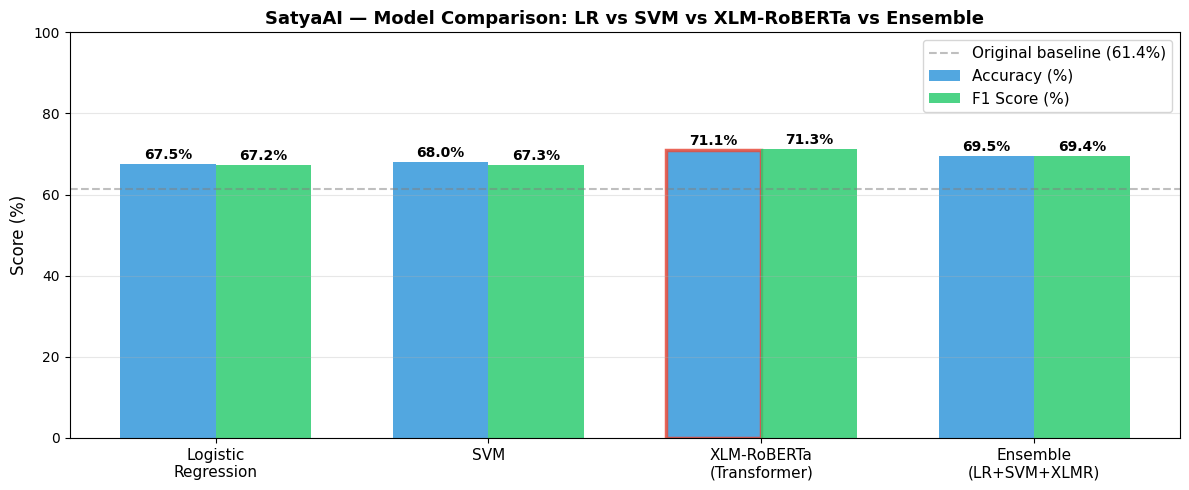


Model                                 Accuracy   F1 Score Winner
─────────────────────────────────────────────────────────────────
Logistic Regression                      67.5%      67.2%
SVM                                      68.0%      67.3%
XLM-RoBERTa (Transformer)                71.1%      71.3% 🏆
Ensemble (LR+SVM+XLMR)                   69.5%      69.4%

📈 Improvement over original baseline (61.4%):
  Logistic Regression                 +6.1%
  SVM                                 +6.6%
  XLM-RoBERTa (Transformer)           +9.7%
  Ensemble (LR+SVM+XLMR)              +8.1%

✅ Comparison chart saved to Drive


In [40]:
# ─── UPDATED MODEL COMPARISON (LR vs SVM vs XLM-RoBERTa vs Ensemble) ───
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# ── Collect all metrics ─────────────────────────────────────────
lr_acc   = round(accuracy_score(y_test, lr_preds)       * 100, 2)
svm_acc  = round(accuracy_score(y_test, svm_preds)      * 100, 2)
xlmr_acc = round(accuracy_score(y_test, xlmr_preds)     * 100, 2)
ens_acc  = round(accuracy_score(y_test, ensemble_preds) * 100, 2)

lr_f1   = round(f1_score(y_test, lr_preds,       average='weighted') * 100, 2)
svm_f1  = round(f1_score(y_test, svm_preds,      average='weighted') * 100, 2)
xlmr_f1 = round(f1_score(y_test, xlmr_preds,    average='weighted') * 100, 2)
ens_f1  = round(f1_score(y_test, ensemble_preds, average='weighted') * 100, 2)

model_names = ["Logistic\nRegression", "SVM", "XLM-RoBERTa\n(Transformer)", "Ensemble\n(LR+SVM+XLMR)"]
accuracies  = [lr_acc,  svm_acc,  xlmr_acc,  ens_acc]
f1_scores   = [lr_f1,   svm_f1,   xlmr_f1,   ens_f1]

# ── Bar Chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(model_names))
width   = 0.35

bars1 = ax.bar(x - width/2, accuracies, width, label="Accuracy (%)", color="#3498db", alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores,  width, label="F1 Score (%)",  color="#2ecc71", alpha=0.85)

for bar in (list(bars1) + list(bars2)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

best_idx = accuracies.index(max(accuracies))
bars1[best_idx].set_edgecolor('#e74c3c')
bars1[best_idx].set_linewidth(2.5)

ax.set_ylim(0, 100)
ax.axhline(y=61.4, color='gray', linestyle='--', alpha=0.5, label='Original baseline (61.4%)')
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("SatyaAI — Model Comparison: LR vs SVM vs XLM-RoBERTa vs Ensemble",
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{base_path}/results/model_comparison_xlmr.png", bbox_inches='tight')
plt.show()

# ── Summary Table ──────────────────────────────────────────────
print(f"\n{'Model':<35} {'Accuracy':>10} {'F1 Score':>10} {'Winner'}")
print("─" * 65)
for i, (name, acc, f1) in enumerate(zip(model_names, accuracies, f1_scores)):
    name = name.replace('\n', ' ')
    star = " 🏆" if acc == max(accuracies) else ""
    print(f"{name:<35} {acc:>9.1f}% {f1:>9.1f}%{star}")

print(f"\n📈 Improvement over original baseline (61.4%):")
for name, acc in zip(model_names, accuracies):
    name = name.replace('\n', ' ')
    gain = round(acc - 61.4, 1)
    print(f"  {name:<35} +{gain}%")

print("\n✅ Comparison chart saved to Drive")


## 13. VALIDATION & EVALUATION

In [41]:
from sklearn.metrics import classification_report, accuracy_score

y_test_pred = model_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

# Debug
print("\nSample Predictions:", y_test_pred[:10])
print("Actual Labels:", y_test[:10].values)

Accuracy: 0.6751269035532995

Classification Report:

              precision    recall  f1-score   support

       FALSE       0.57      0.59      0.58        64
  MISLEADING       0.71      0.62      0.66        86
        TRUE       0.76      0.89      0.82        47

    accuracy                           0.68       197
   macro avg       0.68      0.70      0.69       197
weighted avg       0.67      0.68      0.67       197


Sample Predictions: ['MISLEADING' 'MISLEADING' 'MISLEADING' 'TRUE' 'FALSE' 'TRUE' 'MISLEADING'
 'MISLEADING' 'MISLEADING' 'MISLEADING']
Actual Labels: ['FALSE' 'MISLEADING' 'FALSE' 'MISLEADING' 'MISLEADING' 'TRUE'
 'MISLEADING' 'MISLEADING' 'MISLEADING' 'FALSE']


In [42]:
# 🔹 13A. Cross-Validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_lr, X_train, y_train, cv=5)

print("Cross-validation scores:", cv_scores)
print("Average CV score:", cv_scores.mean())

Cross-validation scores: [0.625      0.66847826 0.67759563 0.6284153  0.6284153 ]
Average CV score: 0.6455808980755524


## CONFIDENCE SCORES

In [43]:
proba = model_lr.predict_proba(X_test)
confidence_scores = [round(max(p) * 100, 2) for p in proba]

# Quick preview
for i in range(5):
    print(f"Claim: {test_df['clean_text'].values[i][:60]}...")
    print(f"  Actual: {y_test.values[i]} | Predicted: {y_test_pred[i]} | Confidence: {confidence_scores[i]}%")
    print()


Claim: rohingya people want travel 1769 km enter india dont want tr...
  Actual: FALSE | Predicted: MISLEADING | Confidence: 42.45%

Claim: discover sansani nahin sirf sach aasif sheikh boom shares co...
  Actual: MISLEADING | Predicted: MISLEADING | Confidence: 40.24%

Claim: akshay kumar tweeted history books teach nathuram godse kill...
  Actual: FALSE | Predicted: MISLEADING | Confidence: 47.34%

Claim: compilation...
  Actual: MISLEADING | Predicted: TRUE | Confidence: 46.17%

Claim: post shared facebook user named ugwu chukwudi richie claims ...
  Actual: MISLEADING | Predicted: FALSE | Confidence: 50.46%



##14. Detailed Evaluation

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_test_pred = model_lr.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.6751269035532995

Classification Report:

              precision    recall  f1-score   support

       FALSE       0.57      0.59      0.58        64
  MISLEADING       0.71      0.62      0.66        86
        TRUE       0.76      0.89      0.82        47

    accuracy                           0.68       197
   macro avg       0.68      0.70      0.69       197
weighted avg       0.67      0.68      0.67       197



## 15. Error Analysis

In [45]:
# 🔹 15. Error Analysis

test_df = test_df.copy()
test_df['predicted'] = y_test_pred

errors = test_df[test_df['label'] != test_df['predicted']]

print("Errors:", len(errors))
print(errors[['claim', 'label', 'predicted']].head())

Errors: 64
                                               claim       label   predicted
0  Rohingya people want to travel 1,769 Km to ent...       FALSE  MISLEADING
2  Akshay Kumar tweeted that history books should...       FALSE  MISLEADING
3                                        Compilation  MISLEADING        TRUE
4  A post shared on Facebook by a user named Ugwu...  MISLEADING       FALSE
9  Bombay High Court passed a judgement that anyo...       FALSE  MISLEADING


## 16 Save Results to Drive (IMPORTANT FIX)

In [46]:
# 🔹 15. Save Results

report = classification_report(y_test, y_test_pred, output_dict=True)

import pandas as pd

pd.DataFrame(report).transpose().to_csv(
    "/content/drive/MyDrive/SatyaAI/results/classification_report.csv"
)

print("Results saved to Drive ✅")

Results saved to Drive ✅


## 17. CONFUSION MATRIX

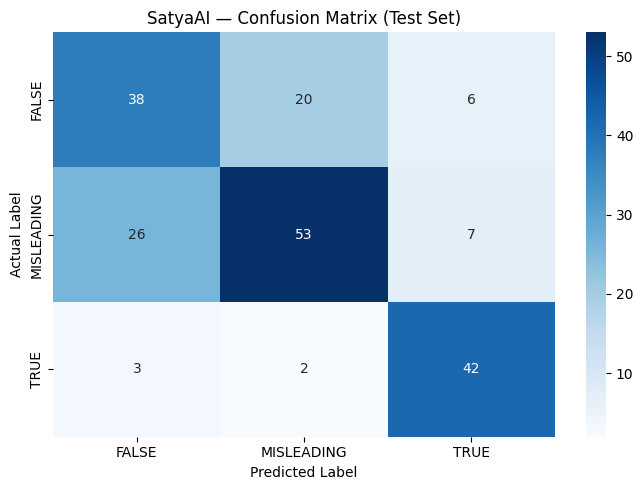

In [47]:
# ─── IMPROVED: CONFUSION MATRIX ──────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_test_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title("SatyaAI — Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(f"{base_path}/results/confusion_matrix.png")
plt.show()


## ROC/AUC Curve

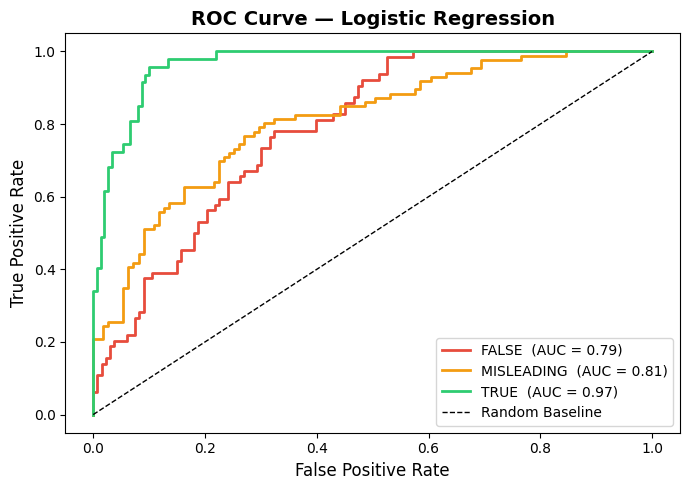

Saved: roc_Logistic_Regression.png


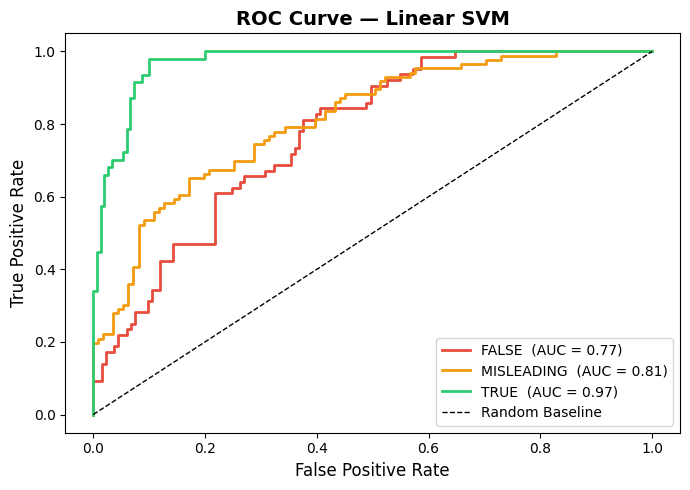

Saved: roc_Linear_SVM.png


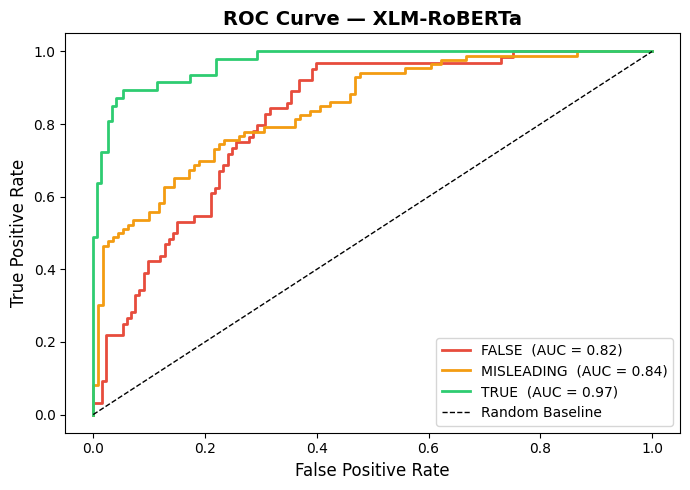

Saved: roc_XLM-RoBERTa.png


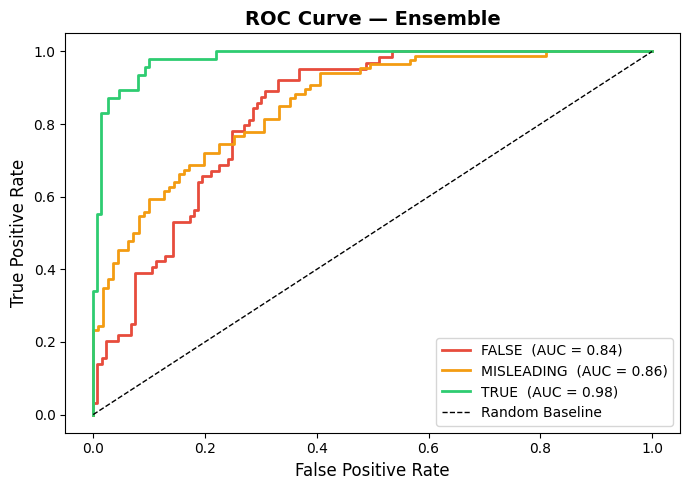

Saved: roc_Ensemble.png


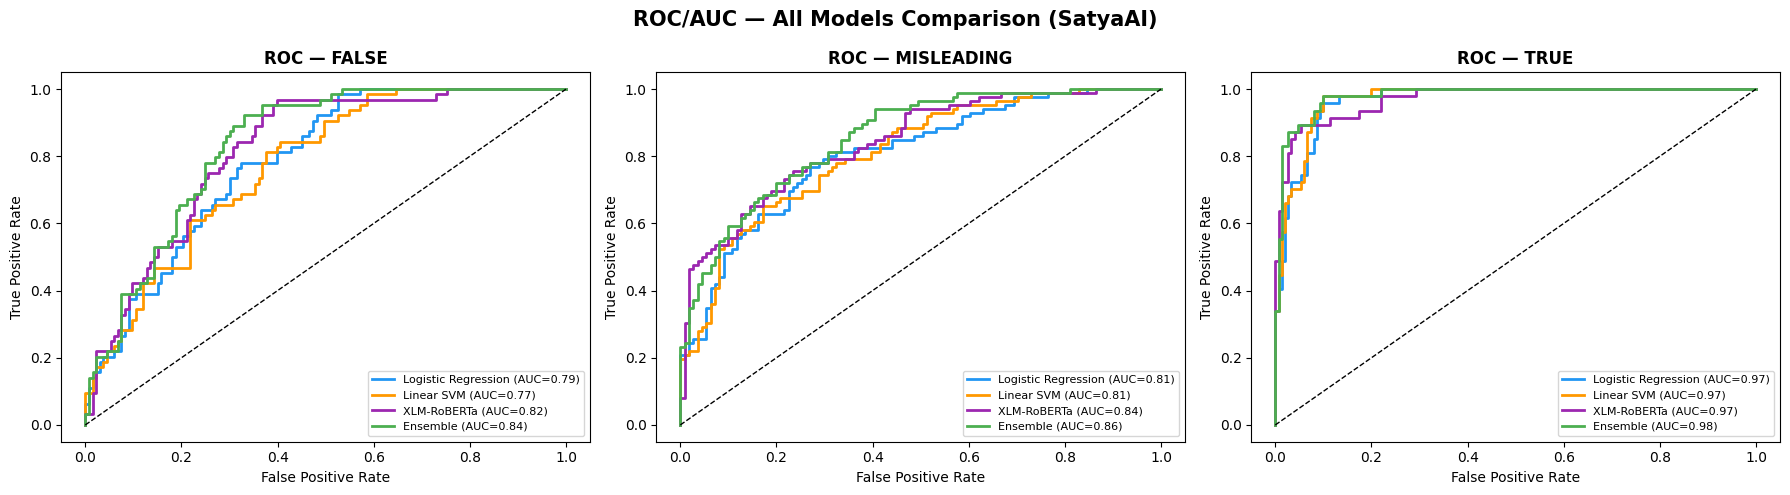

Saved: roc_all_models.png

========== AUC SCORE TABLE ==========
Model                    FALSE   MISLEAD   TRUE   Macro
---------------------------------------------------------
Logistic Regression      0.787     0.808  0.967   0.854
Linear SVM               0.774     0.813   0.97   0.852
XLM-RoBERTa              0.819     0.843   0.97   0.877
Ensemble                 0.835     0.856  0.981   0.891


In [48]:
# ============================================================
# ROC / AUC CURVES — SatyaAI
# Insert after Confusion Matrix cell (Cell 61)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ---- Your variables (already exist from previous cells) ----
# model_lr       → Logistic Regression
# model_svm      → Calibrated SVM
# model_xlmr     → XLM-RoBERTa classifier
# X_test         → TF-IDF test features
# X_test_xlmr    → XLM-RoBERTa test embeddings
# y_test         → true test labels
# classes        → list(model_lr.classes_)  = ['FALSE','MISLEADING','TRUE']

# Step 1: Get probability arrays (already computed but recalculate to be safe)
lr_proba_arr   = model_lr.predict_proba(X_test)
svm_proba_arr  = model_svm.predict_proba(X_test)
xlmr_proba_arr = model_xlmr.predict_proba(X_test_xlmr)
ensemble_proba = (lr_proba_arr + svm_proba_arr + xlmr_proba_arr) / 3.0

# Step 2: Binarize y_test for ROC (One-vs-Rest)
classes = list(model_lr.classes_)   # ['FALSE', 'MISLEADING', 'TRUE']
y_test_bin = label_binarize(y_test, classes=classes)

# Colors for 3 classes
cls_colors = ['#e74c3c', '#f39c12', '#2ecc71']   # FALSE=red, MISLEAD=orange, TRUE=green

# -----------------------------------------------
# PLOT 1: Individual ROC for each model
# -----------------------------------------------
all_models = {
    'Logistic Regression' : lr_proba_arr,
    'Linear SVM'          : svm_proba_arr,
    'XLM-RoBERTa'         : xlmr_proba_arr,
    'Ensemble'            : ensemble_proba
}

for model_name, probs in all_models.items():
    plt.figure(figsize=(7, 5))
    for i, (cls, color) in enumerate(zip(classes, cls_colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{cls}  (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve — {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    save_name = model_name.replace(" ", "_").replace("\n", "")
    plt.savefig(f'{base_path}/results/roc_{save_name}.png', dpi=150)
    plt.show()
    print(f'Saved: roc_{save_name}.png')

# -----------------------------------------------
# PLOT 2: All models on ONE chart (3 subplots, one per class)
# -----------------------------------------------
m_colors = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, cls in enumerate(classes):
    ax = axes[idx]
    for (mname, probs), mc in zip(all_models.items(), m_colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, idx], probs[:, idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=mc, lw=2,
                label=f'{mname} (AUC={roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'ROC — {cls}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('ROC/AUC — All Models Comparison (SatyaAI)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{base_path}/results/roc_all_models.png', dpi=150)
plt.show()
print('Saved: roc_all_models.png')

# -----------------------------------------------
# PRINT AUC TABLE
# -----------------------------------------------
print("\n========== AUC SCORE TABLE ==========")
print(f"{'Model':<22} {'FALSE':>7} {'MISLEAD':>9} {'TRUE':>6} {'Macro':>7}")
print("-" * 57)
for mname, probs in all_models.items():
    row = []
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        row.append(round(auc(fpr, tpr), 3))
    macro = round(sum(row) / len(row), 3)
    print(f"{mname:<22} {row[0]:>7} {row[1]:>9} {row[2]:>6} {macro:>7}")
print("=" * 57)


## 18 STREAMLIT

In [49]:
!pip install -q streamlit pyngrok groq toml

In [50]:
!mkdir -p /root/.streamlit

In [51]:
# ─── Write secrets.toml dynamically from Colab Secrets ───
from google.colab import userdata

NGROK_TOKEN      = userdata.get("NGROK_TOKEN")
GROQ_API_KEY_NLP = userdata.get("GROQ_API_KEY_NLP")
GNEWS_API_KEY    = userdata.get("GNEWS_API_KEY")

secrets_content = f"""
NGROK_TOKEN      = "{NGROK_TOKEN}"
GROQ_API_KEY_NLP = "{GROQ_API_KEY_NLP}"
GNEWS_API_KEY    = "{GNEWS_API_KEY}"
"""

with open("/root/.streamlit/secrets.toml", "w") as f:
    f.write(secrets_content)

print("✅ secrets.toml written from Colab Secrets")


✅ secrets.toml written from Colab Secrets


In [52]:
%%writefile app.py

import streamlit as st
import pickle
import re
import os
import requests
import json
import numpy as np
import torch
import pandas as pd
from datetime import datetime, timedelta
from transformers import AutoTokenizer, AutoModel

# ═══════════════════════════════════════════════════════════════
# PAGE CONFIG
# ═══════════════════════════════════════════════════════════════
st.set_page_config(
    page_title="SatyaAI — Fake News Detector",
    page_icon="📰",
    layout="wide"
)

st.title("📰 SatyaAI — Fake News Detector")
st.caption("Cross-Lingual RAG-Based Fact-Checking System for Regional and Code-Mixed Indian News")

# ═══════════════════════════════════════════════════════════════
# LOAD MODELS
# ═══════════════════════════════════════════════════════════════
@st.cache_resource
def load_models():
    base = "/content/drive/MyDrive/SatyaAI/models"

    # TF-IDF Vectorizer
    tfidf_path = (
        f"{base}/tfidf_v2.pkl"
        if os.path.exists(f"{base}/tfidf_v2.pkl")
        else f"{base}/tfidf.pkl"
    )
    tfidf = pickle.load(open(tfidf_path, "rb"))

    # Logistic Regression
    lr_path = (
        f"{base}/logreg_v2.pkl"
        if os.path.exists(f"{base}/logreg_v2.pkl")
        else f"{base}/logreg.pkl"
    )
    model_lr = pickle.load(open(lr_path, "rb"))

    # SVM
    svm_path  = f"{base}/svm_v2.pkl"
    model_svm = pickle.load(open(svm_path, "rb")) if os.path.exists(svm_path) else None

    # XLM-RoBERTa Classifier (replaces Random Forest)
    xlmr_path  = f"{base}/xlmr_classifier.pkl"
    model_xlmr = pickle.load(open(xlmr_path, "rb")) if os.path.exists(xlmr_path) else None

    return tfidf, model_lr, model_svm, model_xlmr


@st.cache_resource
def load_xlmr_backbone():
    """Load XLM-RoBERTa tokenizer and base model for embedding generation."""
    MODEL_NAME     = "cardiffnlp/twitter-xlm-roberta-base"
    xlmr_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    xlmr_base      = AutoModel.from_pretrained(MODEL_NAME)
    xlmr_base.eval()
    return xlmr_tokenizer, xlmr_base


tfidf, model_lr, model_svm, model_xlmr = load_models()

# ═══════════════════════════════════════════════════════════════
# SESSION STATE
# ═══════════════════════════════════════════════════════════════
if "claim_input" not in st.session_state:
    st.session_state.claim_input = ""

# ═══════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9 ]", "", text)
    return text


def label_badge(label):
    label = str(label).upper()
    if label == "TRUE":
        return "✅ TRUE", "success"
    elif label == "FALSE":
        return "🚨 FALSE", "error"
    else:
        return "⚠️ MISLEADING", "warning"


def get_xlmr_embedding(text, tokenizer, model):
    """Generate XLM-RoBERTa [CLS] embedding for a single text."""
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    )
    with torch.no_grad():
        output = model(**encoded)
    cls_embedding = output.last_hidden_state[:, 0, :].numpy()
    return cls_embedding


def get_evidence(claim, max_articles=3):
    """
    Fetch live news evidence from GNews API.
    Returns: (evidence_text, source_label)
      source_label = "gnews"       → articles found
      source_label = "gnews_empty" → API worked but no articles
      source_label = "gnews_error" → API call failed
    """
    try:
        GNEWS_KEY = st.secrets["GNEWS_API_KEY"]
        from_date = (datetime.now() - timedelta(days=30)).strftime("%Y-%m-%dT%H:%M:%SZ")
        to_date   = datetime.now().strftime("%Y-%m-%dT%H:%M:%SZ")
        keywords  = " ".join(claim.split()[:6])
        url = (
            f"https://gnews.io/api/v4/search"
            f"?q={requests.utils.quote(keywords)}"
            f"&token={GNEWS_KEY}&lang=en"
            f"&max={max_articles}"
            f"&from={from_date}&to={to_date}"
        )
        response = requests.get(url, timeout=10)
        articles = response.json().get("articles", [])

        if not articles:
            return None, "gnews_empty"

        ev = ""
        for i, a in enumerate(articles, 1):
            source_name = a["source"]["name"]
            ev += f"[{i}] {a['title']}\n"
            ev += f"    📰 Source : {source_name}\n"
            ev += f"    🔗 URL    : {a.get('url', 'N/A')}\n"
            ev += f"    📝 Desc   : {a.get('description', 'No description')}\n\n"
        return ev.strip(), "gnews"

    except Exception:
        return None, "gnews_error"


def groq_check(claim, lr_label, lr_conf, xlmr_label, xlmr_conf,
               svm_label, ens_label, evidence_text, evidence_source):
    """Call Groq LLaMA for final AI verdict."""
    try:
        from groq import Groq
        client = Groq(api_key=st.secrets["GROQ_API_KEY_NLP"])

        ml_summary = f"- Logistic Regression  : {lr_label} ({lr_conf}% confidence)\n"
        if xlmr_label != "N/A":
            ml_summary += f"- XLM-RoBERTa          : {xlmr_label} ({xlmr_conf}% confidence)\n"
        if svm_label  != "N/A":
            ml_summary += f"- SVM                  : {svm_label}\n"
        if ens_label  != "N/A":
            ml_summary += f"- Ensemble (best)      : {ens_label}\n"

        if evidence_source == "gnews":
            ev_instruction = (
                "Real-time GNews evidence is provided below. "
                "Use it as your PRIMARY source. "
                "In your reason, cite the article source name."
            )
        else:
            ev_instruction = (
                "No recent GNews evidence found. "
                "Verify using YOUR OWN knowledge and training data. "
                "In your reason, mention that this is based on Groq knowledge."
            )

        system_prompt = f"""You are SatyaAI, an expert Indian fact-checker.
Rules:
1. {ev_instruction}
2. Only mark UNVERIFIABLE if truly cannot determine.
3. Flag low ML confidence (below 60%) as suspicious.
4. Output ONLY valid JSON — no extra text.
Output format:
{{
  "verdict": "REAL or FAKE or UNVERIFIABLE",
  "confidence": <integer 0-100>,
  "reason": "<one clear sentence mentioning where info came from>",
  "source_used": "GNews API" or "Groq Knowledge Base",
  "flags": ["<flag1>", "<flag2>"]
}}"""

        user_prompt = f"""
Claim: {claim}

ML Model Predictions:
{ml_summary}

News Evidence ({evidence_source}):
{evidence_text if evidence_text else "No recent news found. Use your own knowledge."}

Analyse the claim and return your JSON verdict.
"""
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user",   "content": user_prompt}
            ],
            temperature=0.2,
            max_tokens=400
        )
        raw = response.choices[0].message.content.strip()
        try:
            return json.loads(raw)
        except Exception:
            return {
                "verdict"    : "UNVERIFIABLE",
                "confidence" : 0,
                "reason"     : raw,
                "source_used": "Groq Knowledge Base",
                "flags"      : []
            }
    except Exception as e:
        return {
            "verdict"    : "ERROR",
            "confidence" : 0,
            "reason"     : str(e),
            "source_used": "None",
            "flags"      : []
        }


# ═══════════════════════════════════════════════════════════════
# SIDEBAR
# ═══════════════════════════════════════════════════════════════
with st.sidebar:
    st.header("ℹ️ About SatyaAI")
    st.info(
        "📅 **Evidence Search Range**\n\n"
        "Searching news from the **last 30 days** (GNews free tier).\n\n"
        "⚠️ Older claims → Groq verifies using its own knowledge."
    )
    st.markdown("---")
    st.markdown("**🔧 Pipeline**")
    st.markdown(
        "1. 🌐 Input (English / Hindi / Hinglish)\n"
        "2. 🤖 LR + SVM → TF-IDF predictions\n"
        "3. 🧠 XLM-RoBERTa → Transformer prediction\n"
        "4. 🗳️ Soft Voting → Ensemble verdict\n"
        "5. 📰 GNews → Live evidence (last 30 days)\n"
        "6. 🤖 Groq LLaMA → Final AI verdict\n"
        "7. ✅ REAL / FAKE / UNVERIFIABLE"
    )
    st.markdown("---")
    st.markdown("**⚙️ Loaded Models**")
    base_check = "/content/drive/MyDrive/SatyaAI/models"
    st.markdown(f"- TF-IDF       : {'v2 ✅' if os.path.exists(f'{base_check}/tfidf_v2.pkl') else 'v1'}")
    st.markdown(f"- LR           : {'v2 ✅' if os.path.exists(f'{base_check}/logreg_v2.pkl') else 'v1'}")
    st.markdown(f"- SVM          : {'✅' if model_svm else '❌ Not trained yet'}")
    st.markdown(f"- XLM-RoBERTa  : {'✅' if model_xlmr else '❌ Not trained yet'}")
    st.markdown(f"- Random Forest: ❌ Removed (replaced by XLM-RoBERTa)")
    st.markdown("---")
    st.markdown("**🏷️ Label Guide**")
    st.success("✅ TRUE — Verified factual claim")
    st.error("🚨 FALSE — Factually incorrect")
    st.warning("⚠️ MISLEADING — Partially true / out of context")
    st.markdown("---")
    st.markdown("**🌐 Languages Supported**")
    st.markdown("🇬🇧 English  |  🇮🇳 Hindi  |  🔀 Hinglish")

# ═══════════════════════════════════════════════════════════════
# EXAMPLE CLAIMS
# ═══════════════════════════════════════════════════════════════
st.markdown("### 📋 Example Claims to Test")
st.caption("Click any button below to auto-fill the claim ↓")

EXAMPLES = [
    ("🇬🇧 English — TRUE",
     "India won the 2011 ICC Cricket World Cup defeating Sri Lanka by 6 wickets in the final held at Wankhede Stadium Mumbai."),

    ("🇬🇧 English — FALSE",
     "NASA scientists confirmed that drinking hot water with lemon cures COVID-19 completely within 24 hours."),

    ("🔀 Hinglish — FALSE",
     "COVID vaccine lagwane ke baad logo ke andar 5G chip dal di gayi hai jo unka dimag control karti hai."),

    ("🇮🇳 Hindi — MISLEADING",
     "वायरल वीडियो में राहुल गांधी भारत के विभाजन का समर्थन करते हुए दिख रहे हैं।"),
]

for label, text in EXAMPLES:
    col_a, col_b = st.columns([1.5, 5])
    with col_a:
        if st.button(f"Use → {label}", key=f"btn_{label}"):
            st.session_state.claim_input = text
            st.rerun()
    with col_b:
        st.code(text, language=None)

st.markdown("---")

# ═══════════════════════════════════════════════════════════════
# MAIN INPUT
# ═══════════════════════════════════════════════════════════════
st.markdown("### 🔍 Enter a Claim to Verify")

claim = st.text_area(
    "Enter your claim here (English / Hindi / Hinglish)",
    value=st.session_state.claim_input,
    placeholder="e.g. India won the Cricket World Cup in 2011",
    height=100,
)

analyze_btn = st.button("🔍 Analyse Claim", use_container_width=True, type="primary")

# ═══════════════════════════════════════════════════════════════
# ANALYSIS PIPELINE
# ═══════════════════════════════════════════════════════════════
if analyze_btn:

    if not claim.strip():
        st.warning("⚠️ Please enter a claim to verify.")
        st.stop()

    # ── Step 1: TF-IDF Features ────────────────────────────────
    cleaned = clean_text(claim)
    vec     = tfidf.transform([cleaned])

    # ── Step 2: Logistic Regression ────────────────────────────
    lr_label   = model_lr.predict(vec)[0]
    lr_proba   = model_lr.predict_proba(vec)[0]
    lr_conf    = round(max(lr_proba) * 100, 2)
    lr_classes = list(model_lr.classes_)

    # ── Step 3: SVM ────────────────────────────────────────────
    if model_svm is not None:
        svm_label   = model_svm.predict(vec)[0]
        svm_proba   = model_svm.predict_proba(vec)[0]
        svm_conf    = round(max(svm_proba) * 100, 2)
        svm_classes = list(model_svm.classes_)
    else:
        svm_label, svm_conf, svm_proba, svm_classes = "N/A", 0, [], []

    # ── Step 4: XLM-RoBERTa ────────────────────────────────────
    if model_xlmr is not None:
        with st.spinner("🔄 Running XLM-RoBERTa transformer..."):
            xlmr_tokenizer, xlmr_base = load_xlmr_backbone()
            emb = get_xlmr_embedding(claim, xlmr_tokenizer, xlmr_base)

        xlmr_label   = model_xlmr.predict(emb)[0]
        xlmr_proba   = model_xlmr.predict_proba(emb)[0]
        xlmr_conf    = round(max(xlmr_proba) * 100, 2)
        xlmr_classes = list(model_xlmr.classes_)
    else:
        xlmr_label, xlmr_conf, xlmr_proba, xlmr_classes = "N/A", 0, [], []

    # ── Step 5: Soft Voting Ensemble ───────────────────────────
    classes = lr_classes
    if model_xlmr is not None and model_svm is not None:
        ensemble_proba = (lr_proba + svm_proba + xlmr_proba) / 3.0
    elif model_svm is not None:
        ensemble_proba = (lr_proba + svm_proba) / 2.0
    elif model_xlmr is not None:
        ensemble_proba = (lr_proba + xlmr_proba) / 2.0
    else:
        ensemble_proba = lr_proba

    ens_label = classes[int(np.argmax(ensemble_proba))]
    ens_conf  = round(max(ensemble_proba) * 100, 2)

    # ── Step 6: Fetch GNews Evidence ───────────────────────────
    with st.spinner("📰 Fetching live news evidence..."):
        evidence, evidence_source = get_evidence(claim)

    st.markdown("---")

    # ═══════════════════════════════════════════════════════════
    # ROW 1: LR | XLM-RoBERTa | Evidence
    # ═══════════════════════════════════════════════════════════
    st.subheader("📊 ML Model Predictions")
    col_lr, col_xlmr, col_ev = st.columns([1, 1, 2])

    # ── Logistic Regression ────────────────────────────────────
    with col_lr:
        st.markdown("**🔵 Logistic Regression**")
        lr_text, lr_type = label_badge(lr_label)
        if lr_type == "success":
            st.success(f"{lr_text}\n\n**Confidence: {lr_conf}%**")
        elif lr_type == "error":
            st.error(f"{lr_text}\n\n**Confidence: {lr_conf}%**")
        else:
            st.warning(f"{lr_text}\n\n**Confidence: {lr_conf}%**")
        st.progress(int(lr_conf))
        with st.expander("Class Probabilities"):
            for cls, prob in zip(lr_classes, lr_proba):
                st.write(f"`{cls}`: {round(prob*100, 1)}%")
        if lr_conf < 60:
            st.caption("⚠️ Low confidence — model is unsure")

    # ── XLM-RoBERTa ───────────────────────────────────────────
    with col_xlmr:
        st.markdown("**🟣 XLM-RoBERTa (Transformer)**")
        if model_xlmr is None:
            st.info(
                "XLM-RoBERTa model not found.\n\n"
                "Run Cell 12B in your notebook first."
            )
        else:
            xlmr_text, xlmr_type = label_badge(xlmr_label)
            if xlmr_type == "success":
                st.success(f"{xlmr_text}\n\n**Confidence: {xlmr_conf}%**")
            elif xlmr_type == "error":
                st.error(f"{xlmr_text}\n\n**Confidence: {xlmr_conf}%**")
            else:
                st.warning(f"{xlmr_text}\n\n**Confidence: {xlmr_conf}%**")
            st.progress(int(xlmr_conf))
            with st.expander("Class Probabilities"):
                for cls, prob in zip(xlmr_classes, xlmr_proba):
                    st.write(f"`{cls}`: {round(prob*100, 1)}%")
            if xlmr_conf < 60:
                st.caption("⚠️ Low confidence — model is unsure")

    # ── Live News Evidence ─────────────────────────────────────
    with col_ev:
        st.markdown("**📰 Live News Evidence**")
        st.caption("📅 Last 30 days  |  🔍 GNews API")

        if evidence and evidence_source == "gnews":
            st.success("✅ Evidence retrieved from **GNews API**")
            st.markdown("📡 **Source: GNews API — Real-time News Articles**")
            st.text(evidence)
        elif evidence_source == "gnews_empty":
            st.warning("📭 No news articles found in GNews (last 30 days).")
            st.info(
                "🧠 **Fallback Source: Groq LLaMA Knowledge Base**\n\n"
                "Groq will verify this claim using its own training knowledge."
            )
        else:
            st.warning("⚠️ Could not reach GNews API.")
            st.info(
                "🧠 **Fallback Source: Groq LLaMA Knowledge Base**\n\n"
                "Groq will verify this claim using its own training knowledge."
            )

    # ═══════════════════════════════════════════════════════════
    # ROW 2: SVM | Ensemble
    # ═══════════════════════════════════════════════════════════
    st.markdown("---")
    col_svm, col_ens = st.columns(2)

    # ── SVM ───────────────────────────────────────────────────
    with col_svm:
        st.markdown("**🟠 SVM (Linear)**")
        if model_svm is None:
            st.info(
                "SVM model not found.\n\n"
                "Run the SVM training cell in your notebook first."
            )
        else:
            svm_text, svm_type = label_badge(svm_label)
            if svm_type == "success":
                st.success(f"{svm_text}\n\n**Confidence: {svm_conf}%**")
            elif svm_type == "error":
                st.error(f"{svm_text}\n\n**Confidence: {svm_conf}%**")
            else:
                st.warning(f"{svm_text}\n\n**Confidence: {svm_conf}%**")
            st.progress(int(svm_conf))
            with st.expander("Class Probabilities"):
                for cls, prob in zip(svm_classes, svm_proba):
                    st.write(f"`{cls}`: {round(prob*100, 1)}%")
            if svm_conf < 60:
                st.caption("⚠️ Low confidence — model is unsure")

    # ── Ensemble ──────────────────────────────────────────────
    with col_ens:
        st.markdown("**🏆 Ensemble (LR + SVM + XLM-RoBERTa)**")
        ens_text, ens_type = label_badge(ens_label)
        if ens_type == "success":
            st.success(f"{ens_text}\n\n**Ensemble Confidence: {ens_conf}%**")
        elif ens_type == "error":
            st.error(f"{ens_text}\n\n**Ensemble Confidence: {ens_conf}%**")
        else:
            st.warning(f"{ens_text}\n\n**Ensemble Confidence: {ens_conf}%**")
        st.progress(int(ens_conf))
        with st.expander("Ensemble Class Probabilities"):
            for cls, prob in zip(classes, ensemble_proba):
                st.write(f"`{cls}`: {round(prob*100, 1)}%")

    # ═══════════════════════════════════════════════════════════
    # GROQ LLaMA FINAL VERDICT
    # ═══════════════════════════════════════════════════════════
    st.markdown("---")
    st.subheader("🧠 Groq LLaMA — Final AI Verdict")

    with st.spinner("🤖 Asking Groq LLaMA for final verdict..."):
        groq_result = groq_check(
            claim          = claim,
            lr_label       = lr_label,
            lr_conf        = lr_conf,
            xlmr_label     = xlmr_label,
            xlmr_conf      = xlmr_conf,
            svm_label      = svm_label,
            ens_label      = ens_label,
            evidence_text  = evidence if evidence else "No recent news found.",
            evidence_source= evidence_source
        )

    verdict     = groq_result.get("verdict",     "UNVERIFIABLE")
    confidence  = groq_result.get("confidence",  0)
    reason      = groq_result.get("reason",      "No reason provided.")
    source_used = groq_result.get("source_used", "Groq Knowledge Base")
    flags       = groq_result.get("flags",       [])

    col_v1, col_v2 = st.columns([1, 2])

    with col_v1:
        if verdict == "REAL":
            st.success(f"## ✅ {verdict}")
        elif verdict == "FAKE":
            st.error(f"## 🚨 {verdict}")
        elif verdict == "UNVERIFIABLE":
            st.warning(f"## ❓ {verdict}")
        else:
            st.error(f"## ⚠️ {verdict}")

        st.metric("AI Confidence", f"{confidence}%")
        st.progress(int(confidence))

    with col_v2:
        st.markdown("**📝 Reasoning:**")
        st.info(reason)

        # Show source of verification
        if source_used == "GNews API":
            st.success(
                "📡 **Verified using: GNews API**\n\n"
                "This verdict is based on real-time news articles retrieved from GNews."
            )
        else:
            st.info(
                "🧠 **Verified using: Groq LLaMA Knowledge Base**\n\n"
                "No recent GNews articles were found. "
                "This verdict is based on Groq's internal training knowledge."
            )

        if flags:
            st.markdown("**🚩 Flags:**")
            for flag in flags:
                st.markdown(f"- {flag}")

    # ═══════════════════════════════════════════════════════════
    # MODEL AGREEMENT SUMMARY TABLE
    # ═══════════════════════════════════════════════════════════
    st.markdown("---")
    st.subheader("📋 Model Agreement Summary")

    summary_data = {
        "Model"      : ["Logistic Regression", "XLM-RoBERTa", "SVM", "Ensemble", "Groq LLaMA"],
        "Prediction" : [lr_label, xlmr_label, svm_label, ens_label, verdict],
        "Confidence" : [
            f"{lr_conf}%",
            f"{xlmr_conf}%" if xlmr_label != "N/A" else "—",
            f"{svm_conf}%"  if svm_label  != "N/A" else "—",
            f"{ens_conf}%",
            f"{confidence}%"
        ],
        "Source" : [
            "TF-IDF Features",
            "Transformer Embeddings",
            "TF-IDF Features",
            "Soft Voting (LR+SVM+XLMR)",
            source_used
        ]
    }

    st.table(pd.DataFrame(summary_data))

    st.markdown("---")
    st.caption(
        "🔬 SatyaAI — Built with XLM-RoBERTa + TF-IDF (LR + SVM) + Groq LLaMA | NLP Project 2025"
    )


Overwriting app.py


In [53]:
!pkill -f streamlit
!pkill -f ngrok

In [54]:
import subprocess

subprocess.Popen(
    ["streamlit", "run", "app.py"],
)

<Popen: returncode: None args: ['streamlit', 'run', 'app.py']>

In [55]:
import toml
from pyngrok import ngrok
import time

secrets = toml.load("/root/.streamlit/secrets.toml")

NGROK_TOKEN = secrets["NGROK_TOKEN"]

ngrok.set_auth_token(NGROK_TOKEN)

time.sleep(8)

url = ngrok.connect(8501)

print("🚀 Open this link:")
print(url)

🚀 Open this link:
NgrokTunnel: "https://throat-grandpa-citizen.ngrok-free.dev" -> "http://localhost:8501"


## Prediction Log

In [56]:
# # ─── LAST CELL: SAVE TEST SET PREDICTION LOG ──────────
# import pandas as pd
# from datetime import datetime
# from sklearn.metrics import accuracy_score

# # Use notebook variables that already exist
# log_entries = []

# for i in range(len(y_test)):
#     proba = model_lr.predict_proba(X_test[i])
#     conf  = round(max(proba[0]) * 100, 2)

#     log_entries.append({
#         "timestamp"      : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
#         "claim"          : test_df['clean_text'].values[i][:150],
#         "actual_label"   : y_test.values[i],
#         "ml_predicted"   : y_test_pred[i],
#         "ml_confidence"  : conf,
#         "correct"        : y_test.values[i] == y_test_pred[i]
#     })

# log_df   = pd.DataFrame(log_entries)
# log_path = f"{base_path}/logs/prediction_log.csv"

# log_df.to_csv(log_path, index=False)

# print(f"✅ Log saved → {log_path}")
# print(f"   Total entries : {len(log_df)}")
# print(f"   Accuracy      : {round(log_df['correct'].mean() * 100, 2)}%")
# print(f"\nSample:")
# print(log_df[['actual_label','ml_predicted','ml_confidence','correct']].head())


In [57]:
# Find claims your model already predicts TRUE correctly
test_df = pd.read_csv(f'{base_path}/data/processed/test.csv')

true_claims = test_df[test_df['label'] == 'TRUE'].copy()
true_claims['clean'] = true_claims['claim'].apply(preprocess_text)

X_true = combined_tfidf.transform(true_claims['clean'])
true_claims['predicted'] = model_lr.predict(X_true)

# Find ones where model correctly says TRUE
correct_true = true_claims[true_claims['predicted'] == 'TRUE']

print(f"Correctly predicted TRUE: {len(correct_true)}")
print("\nTop claims to use in demo:")
print(correct_true[['claim', 'language']].head(20).to_string())

Correctly predicted TRUE: 42

Top claims to use in demo:
                                                                                                                                                                                       claim  language
5                                                                                              "Adjusting for inflation, West Virginia’s median household income has not grown in a decade."        en
12                                                                                                                       13,000 training centers opened across India training in 376 trades.        en
16                                                                                                      "The United States is the ONLY industrialized country without universal healthcare."        en
21                                                                     Sources ke anusar yeh viral image with the Aaj Tak logo of Jyoti Malhotra we